# Pipeline Completo: Predicción de Segundo Matrimonio
> Preprocesamiento → Modelos XGBoost → Evaluación Final

## Paso 1 · Imports y Configuración

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
)

# ── Configuración global ──────────────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.30

# Tres configuraciones de XGBoost a comparar
XGB_CONFIGS = [
    {
        "n_estimators": 200,
        "max_depth": 4,
        "learning_rate": 0.1,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "scale_pos_weight": 9,   # ~ratio clase mayoritaria / minoritaria
        "label": "Modelo 1 (conservador)",
    },
    {
        "n_estimators": 400,
        "max_depth": 6,
        "learning_rate": 0.05,
        "subsample": 0.7,
        "colsample_bytree": 0.7,
        "scale_pos_weight": 9,
        "min_child_weight": 3,
        "label": "Modelo 2 (profundo)",
    },
    {
        "n_estimators": 300,
        "max_depth": 5,
        "learning_rate": 0.08,
        "subsample": 0.9,
        "colsample_bytree": 0.6,
        "scale_pos_weight": 9,
        "reg_alpha": 0.1,       # regularización L1
        "reg_lambda": 1.5,      # regularización L2
        "label": "Modelo 3 (regularizado)",
    },
]

print("✓ Librerías cargadas y configuración lista.")

✓ Librerías cargadas y configuración lista.


## Paso 2 · Carga de Datasets Preprocesados
> Se reutilizan los CSV generados en el pipeline de Random Forest (Avances3.ipynb)

In [2]:
# Cargar los datasets ya preprocesados y balanceados con SMOTE
X_train_final = pd.read_csv("X_train_final.csv")
y_train_final = pd.read_csv("y_train_final.csv").squeeze()
X_test_final  = pd.read_csv("X_test_final.csv")
y_test_final  = pd.read_csv("y_test_final.csv").squeeze()

cols_modelo = X_train_final.columns.tolist()

# Calcular scale_pos_weight real del dataset
conteo = y_train_final.value_counts()
scale_pos_weight_real = round(conteo[0] / conteo[1], 2)

print(f"Train: {X_train_final.shape} | Test: {X_test_final.shape}")
print(f"Features ({len(cols_modelo)}): {cols_modelo}")
print(f"\nBalance train (post-SMOTE):")
print(conteo)
print(f"\nscale_pos_weight calculado: {scale_pos_weight_real}")
print("\nBalance test:")
print(y_test_final.value_counts())

Train: (651660, 9) | Test: (153340, 9)
Features (9): ['AÑOREG', 'AÑOOCU', 'EDADHOM', 'EDADMUJ', 'DIAOCU', 'DIVORCIO', 'EDADM', 'DIFERENCIA_EDAD', 'EDAD_PROMEDIO']

Balance train (post-SMOTE):
SEGUNDO_MATRIMONIO
0    325830
1    325830
Name: count, dtype: int64

scale_pos_weight calculado: 1.0

Balance test:
SEGUNDO_MATRIMONIO
0    139641
1     13699
Name: count, dtype: int64


## Paso 3 · Funciones de Modelado y Evaluación

In [3]:
def entrenar_evaluar_xgb(config: dict, X_train, y_train, X_test, y_test) -> dict:
    """Entrena un modelo XGBoost y retorna métricas."""
    label = config.pop("label")
    clf   = XGBClassifier(
        **config,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        use_label_encoder=False,
        n_jobs=-1,
    )
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    probs = clf.predict_proba(X_test)[:, 1]

    metricas = {
        "Modelo":    label,
        "Accuracy":  round(accuracy_score(y_test, preds),  4),
        "Precision": round(precision_score(y_test, preds, zero_division=0), 4),
        "Recall":    round(recall_score(y_test, preds, zero_division=0), 4),
        "F1-score":  round(f1_score(y_test, preds, zero_division=0), 4),
        "ROC-AUC":   round(roc_auc_score(y_test, probs), 4),
    }
    return {"label": label, "modelo": clf, "preds": preds, "probs": probs, **metricas}


def plot_confusion_matrix(y_test, preds, label: str, ax=None):
    cm   = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["1er matrimonio", "2do matrimonio"]
    )
    disp.plot(ax=ax, values_format="d", colorbar=False)
    (ax or plt.gca()).set_title(f"Matriz de Confusión\n{label}")


def plot_roc(modelo, X_test, y_test, label: str, ax=None):
    RocCurveDisplay.from_estimator(modelo, X_test, y_test, ax=ax, name=label)
    (ax or plt.gca()).set_title("Curva ROC")


def plot_importancia(modelo, feature_names, label: str, top_n: int = 10):
    """Visualiza feature importance de XGBoost."""
    df_imp = (
        pd.DataFrame({"Variable": feature_names, "Importancia": modelo.feature_importances_})
        .sort_values("Importancia", ascending=False)
        .head(top_n)
    )
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(x="Importancia", y="Variable", data=df_imp, ax=ax, palette="Oranges_r")
    ax.set_title(f"Top {top_n} Variables más Importantes — {label}")
    plt.tight_layout()
    plt.savefig(f"importancia_XGB_{label.replace(' ', '_')}.png", dpi=150)
    plt.show()
    return df_imp


print("✓ Funciones de modelado definidas.")

✓ Funciones de modelado definidas.


## Paso 4 · Entrenar y Comparar los 3 Modelos Base

In [4]:
resultados = []
modelos    = []

for cfg in XGB_CONFIGS:
    cfg_copy = cfg.copy()
    res = entrenar_evaluar_xgb(cfg_copy, X_train_final, y_train_final, X_test_final, y_test_final)
    resultados.append(res)
    modelos.append(res)
    print(f"\n{'='*45}")
    print(f"  {res['label']}")
    print(f"{'='*45}")
    print(f"  Accuracy : {res['Accuracy']}")
    print(f"  Precision: {res['Precision']}")
    print(f"  Recall   : {res['Recall']}")
    print(f"  F1-score : {res['F1-score']}")
    print(f"  ROC-AUC  : {res['ROC-AUC']}")

df_comparacion = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ("modelo", "preds", "probs")}
    for r in resultados
])

print("\n\nResumen comparativo:")
display(df_comparacion)

C:\Users\chris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [09:13:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



  Modelo 1 (conservador)
  Accuracy : 0.4452
  Precision: 0.137
  Recall   : 0.983
  F1-score : 0.2405
  ROC-AUC  : 0.7584


C:\Users\chris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [09:13:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



  Modelo 2 (profundo)
  Accuracy : 0.4713
  Precision: 0.1415
  Recall   : 0.9704
  F1-score : 0.247
  ROC-AUC  : 0.7556


C:\Users\chris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [09:13:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



  Modelo 3 (regularizado)
  Accuracy : 0.4613
  Precision: 0.1399
  Recall   : 0.9766
  F1-score : 0.2447
  ROC-AUC  : 0.7563


Resumen comparativo:


,label,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Modelo 1 (conservador),Modelo 1 (conservador),0.4452,0.1370,0.9830,0.2405,0.7584
1,Modelo 2 (profundo),Modelo 2 (profundo),0.4713,0.1415,0.9704,0.2470,0.7556
2,Modelo 3 (regularizado),Modelo 3 (regularizado),0.4613,0.1399,0.9766,0.2447,0.7563


## Paso 5 · Matrices de Confusión — Comparación Visual

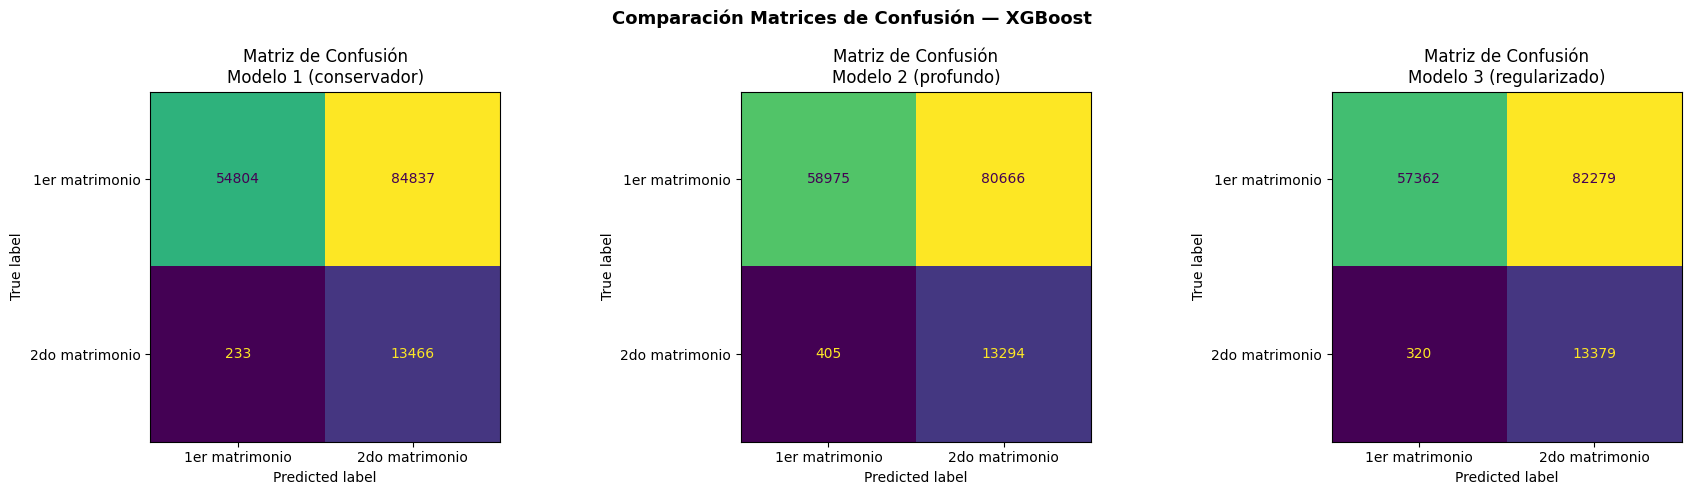

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, res in zip(axes, modelos):
    plot_confusion_matrix(y_test_final, res["preds"], res["label"], ax=ax)
plt.suptitle("Comparación Matrices de Confusión — XGBoost", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrices_XGB.png", dpi=150)
plt.show()

## Paso 6 · Curvas ROC — Comparación Visual

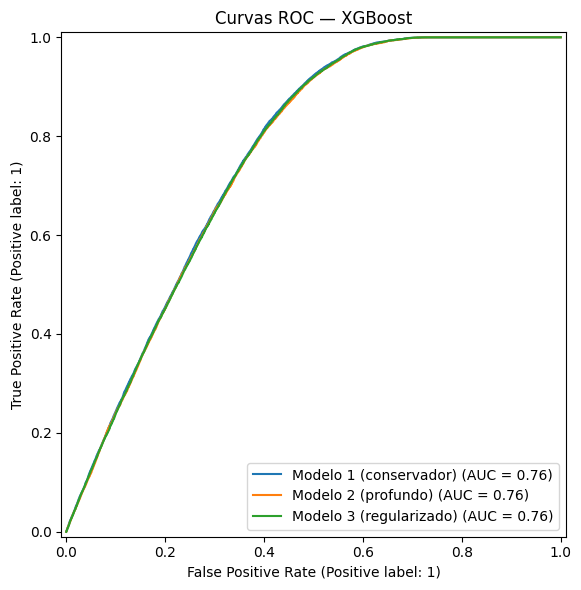

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
for res in modelos:
    RocCurveDisplay.from_estimator(
        res["modelo"], X_test_final, y_test_final, ax=ax, name=res["label"]
    )
ax.set_title("Curvas ROC — XGBoost")
plt.tight_layout()
plt.savefig("roc_XGB.png", dpi=150)
plt.show()

## Paso 7 · Búsqueda de Hiperparámetros (RandomizedSearchCV)

In [7]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Muestra estratificada del 20% para acelerar la búsqueda
X_sample, _, y_sample, _ = train_test_split(
    X_train_final, y_train_final,
    train_size=0.20,
    stratify=y_train_final,
    random_state=RANDOM_STATE
)

param_dist = {
    "n_estimators":      [200, 300, 400, 500],
    "max_depth":         [3, 4, 5, 6, 8],
    "learning_rate":     [0.01, 0.05, 0.08, 0.1, 0.2],
    "subsample":         [0.6, 0.7, 0.8, 0.9],
    "colsample_bytree":  [0.5, 0.6, 0.7, 0.8],
    "min_child_weight":  [1, 3, 5],
    "reg_alpha":         [0, 0.1, 0.5, 1.0],
    "reg_lambda":        [1.0, 1.5, 2.0],
    "scale_pos_weight":  [scale_pos_weight_real],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

search_xgb = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        use_label_encoder=False,
        n_jobs=-1,
    ),
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=cv,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

search_xgb.fit(X_sample, y_sample)

print(f"\n✓ Mejores hiperparámetros encontrados:")
print(search_xgb.best_params_)
print(f"  Mejor F1 CV: {search_xgb.best_score_:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits


C:\Users\chris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [09:15:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



✓ Mejores hiperparámetros encontrados:
{'subsample': 0.6, 'scale_pos_weight': 1.0, 'reg_lambda': 1.5, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.5}
  Mejor F1 CV: 0.8707


## Paso 8 · Modelo Optimizado — Entrenamiento Final

In [8]:
# Reentrenar con los mejores parámetros sobre TODO el train
modelo_opt_xgb = XGBClassifier(
    **search_xgb.best_params_,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
    use_label_encoder=False,
    n_jobs=-1,
)
modelo_opt_xgb.fit(X_train_final, y_train_final)

pred_opt  = modelo_opt_xgb.predict(X_test_final)
probs_opt = modelo_opt_xgb.predict_proba(X_test_final)[:, 1]
label_opt = "Modelo Optimizado XGB"

print(f"\n{'='*45}")
print(f"  MODELO OPTIMIZADO — XGBoost")
print(f"{'='*45}")
print(classification_report(y_test_final, pred_opt, zero_division=0))
print(f"  Accuracy : {accuracy_score(y_test_final, pred_opt):.4f}")
print(f"  F1       : {f1_score(y_test_final, pred_opt, average='weighted'):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test_final, probs_opt):.4f}")
print(f"  Hiperparámetros: {search_xgb.best_params_}")

C:\Users\chris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [09:17:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



  MODELO OPTIMIZADO — XGBoost
              precision    recall  f1-score   support

           0       0.91      0.98      0.95    139641
           1       0.17      0.04      0.06     13699

    accuracy                           0.90    153340
   macro avg       0.54      0.51      0.50    153340
weighted avg       0.85      0.90      0.87    153340

  Accuracy : 0.8981
  F1       : 0.8671
  ROC-AUC  : 0.7471
  Hiperparámetros: {'subsample': 0.6, 'scale_pos_weight': 1.0, 'reg_lambda': 1.5, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.5}


## Paso 9 · Evaluación Final del Mejor Modelo

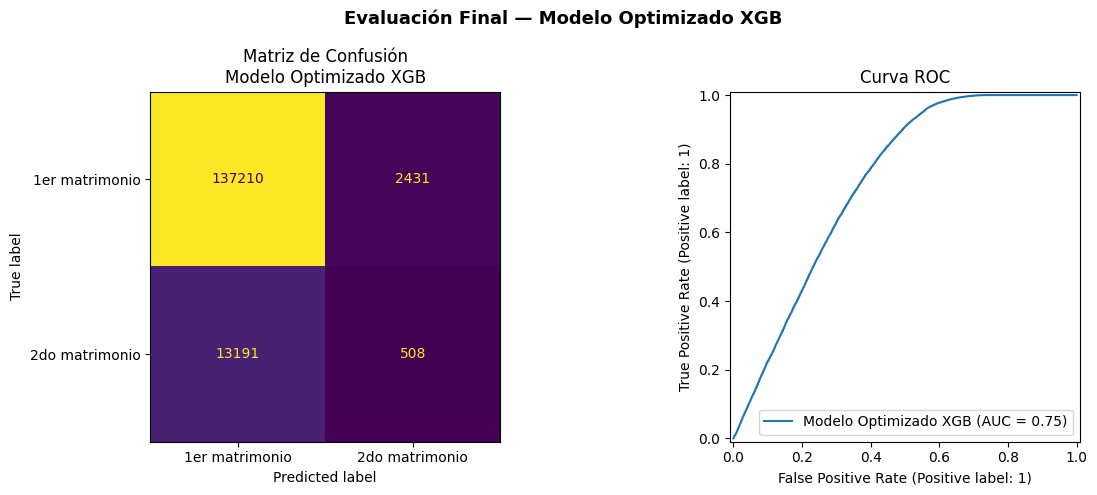

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_confusion_matrix(y_test_final, pred_opt, label_opt, ax=axes[0])
plot_roc(modelo_opt_xgb, X_test_final, y_test_final, label_opt, ax=axes[1])
plt.suptitle(f"Evaluación Final — {label_opt}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("evaluacion_final_XGB.png", dpi=150)
plt.show()

## Paso 10 · Importancia de Variables y Guardado de Resultados

C:\Users\chris\AppData\Local\Temp\ipykernel_23648\1167120328.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importancia", y="Variable", data=df_imp, ax=ax, palette="Oranges_r")


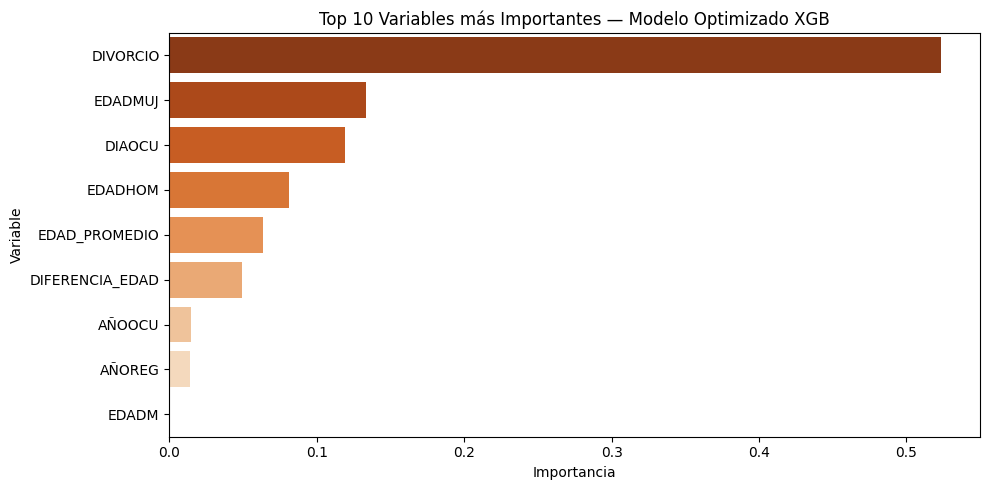


Top 10 variables más importantes:


,Variable,Importancia
5,DIVORCIO,0.523723
3,EDADMUJ,0.133508
4,DIAOCU,0.119495
2,EDADHOM,0.081006
8,EDAD_PROMEDIO,0.063325
7,DIFERENCIA_EDAD,0.049455
1,AÑOOCU,0.014852
0,AÑOREG,0.014123
6,EDADM,0.000512



✓ Archivos guardados:
  comparacion_modelos_XGB.csv
  importancia_XGB.csv
  evaluacion_final_XGB.png
  confusion_matrices_XGB.png
  roc_XGB.png

Comparación final de todos los modelos XGB:


,label,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Modelo 1 (conservador),Modelo 1 (conservador),0.4452,0.1370,0.9830,0.2405,0.7584
1,Modelo 2 (profundo),Modelo 2 (profundo),0.4713,0.1415,0.9704,0.2470,0.7556
2,Modelo 3 (regularizado),Modelo 3 (regularizado),0.4613,0.1399,0.9766,0.2447,0.7563
3,NaN,Modelo Optimizado XGB,0.8981,0.1728,0.0371,0.0611,0.7471


In [10]:
df_importancia = plot_importancia(modelo_opt_xgb, cols_modelo, label_opt, top_n=10)

print("\nTop 10 variables más importantes:")
display(df_importancia)

# Consolidar resultados incluyendo el modelo optimizado
fila_opt = {
    "Modelo":    label_opt,
    "Accuracy":  round(accuracy_score(y_test_final, pred_opt), 4),
    "Precision": round(precision_score(y_test_final, pred_opt, zero_division=0), 4),
    "Recall":    round(recall_score(y_test_final, pred_opt, zero_division=0), 4),
    "F1-score":  round(f1_score(y_test_final, pred_opt, zero_division=0), 4),
    "ROC-AUC":   round(roc_auc_score(y_test_final, probs_opt), 4),
}
df_comparacion = pd.concat(
    [df_comparacion, pd.DataFrame([fila_opt])], ignore_index=True
)

df_comparacion.to_csv("comparacion_modelos_XGB.csv", index=False)
df_importancia.to_csv("importancia_XGB.csv", index=False)

print("\n✓ Archivos guardados:")
print("  comparacion_modelos_XGB.csv")
print("  importancia_XGB.csv")
print("  evaluacion_final_XGB.png")
print("  confusion_matrices_XGB.png")
print("  roc_XGB.png")

print("\nComparación final de todos los modelos XGB:")
display(df_comparacion)